### EEG Motor Imagery CNN+LSTM
# Motor Imagery (MI): Decoding movement intentions (e.g., left/right hand flexion).

In [86]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, Dropout, Dense
from tensorflow.keras.layers import MaxPooling1D, LSTM, Reshape
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from scipy.fft import fft


In [87]:
# Suppress CUDA warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [88]:
data = pd.read_csv('BCICIV_2a_all_patients.csv')
data.head(10)

,patient,time,label,epoch,EEG-Fz,EEG-0,EEG-1,EEG-2,EEG-3,EEG-4,...,EEG-8,EEG-9,EEG-10,EEG-11,EEG-12,EEG-13,EEG-14,EEG-Pz,EEG-15,EEG-16
0,1,-0.100,tongue,8,-1.681412,2.245496,-0.158350,1.163765,-1.523659,-0.575267,...,0.758116,3.441785,0.305517,1.137473,-1.275763,-2.898359,0.656704,-2.010063,-1.613804,-1.942455
1,1,-0.096,tongue,8,0.420417,0.587559,1.650510,0.970672,1.505904,0.891796,...,1.541586,-0.071620,0.258909,-1.448198,0.142472,-1.968405,-1.733655,-2.935578,-3.125256,-4.674610
2,1,-0.092,tongue,8,0.551365,1.499758,0.121302,2.859433,2.613414,4.636026,...,2.649097,-2.137938,-1.612096,-1.610218,-0.410173,-0.274957,-4.776535,-5.099551,-2.798995,-5.862021
3,1,-0.088,tongue,8,3.054916,-1.807238,1.843603,2.286812,5.995872,6.651295,...,6.031554,-5.249621,-2.672998,-3.452370,0.189081,1.593829,-6.081577,-5.476860,-2.932163,-6.874095
4,1,-0.084,tongue,8,2.506710,-2.453101,0.221178,0.127278,4.519931,6.249573,...,7.827097,-5.309546,-2.488783,-3.707608,1.447515,4.268278,-4.383690,-4.218426,-1.331932,-5.322692
5,1,-0.080,tongue,8,1.150619,-2.051379,-0.402491,0.529000,3.554466,4.551686,...,8.082335,-3.882433,-1.354639,-2.719949,0.823847,3.986407,-3.835483,-3.523735,-2.443882,-7.118236
6,1,-0.076,tongue,8,-1.537147,-2.151255,-2.943773,-0.498610,1.062012,4.061185,...,5.736366,-1.345590,-1.503343,-1.599121,2.725924,4.521297,-0.370906,-0.205642,0.092961,-2.921236
7,1,-0.072,tongue,8,-2.979796,-4.765779,-4.825875,-3.308447,-1.503684,1.934942,...,8.395279,1.362151,0.667289,-0.063255,1.234447,4.934116,2.043867,1.379053,1.384687,-0.945917
8,1,-0.068,tongue,8,-4.742048,-2.963577,-6.099845,-3.312886,-5.072576,1.491050,...,4.484590,4.580368,-0.460197,0.518244,1.718289,4.734365,4.041381,2.790630,2.063842,1.979332
9,1,-0.064,tongue,8,-5.061650,-1.964820,-5.052260,-5.390301,-6.271085,-1.855896,...,0.747019,5.383813,1.270982,2.102939,0.080327,2.461637,5.626076,3.887043,3.013771,4.589417


In [89]:
data.shape

(492048, 26)

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492048 entries, 0 to 492047
Data columns (total 26 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   patient  492048 non-null  int64  
 1   time     492048 non-null  float64
 2   label    492048 non-null  object 
 3   epoch    492048 non-null  int64  
 4   EEG-Fz   492048 non-null  float64
 5   EEG-0    492048 non-null  float64
 6   EEG-1    492048 non-null  float64
 7   EEG-2    492048 non-null  float64
 8   EEG-3    492048 non-null  float64
 9   EEG-4    492048 non-null  float64
 10  EEG-5    492048 non-null  float64
 11  EEG-C3   492048 non-null  float64
 12  EEG-6    492048 non-null  float64
 13  EEG-Cz   492048 non-null  float64
 14  EEG-7    492048 non-null  float64
 15  EEG-C4   492048 non-null  float64
 16  EEG-8    492048 non-null  float64
 17  EEG-9    492048 non-null  float64
 18  EEG-10   492048 non-null  float64
 19  EEG-11   492048 non-null  float64
 20  EEG-12   492048 non-null  

In [91]:
data.isna().sum()

patient    0
time       0
label      0
epoch      0
EEG-Fz     0
EEG-0      0
EEG-1      0
EEG-2      0
EEG-3      0
EEG-4      0
EEG-5      0
EEG-C3     0
EEG-6      0
EEG-Cz     0
EEG-7      0
EEG-C4     0
EEG-8      0
EEG-9      0
EEG-10     0
EEG-11     0
EEG-12     0
EEG-13     0
EEG-14     0
EEG-Pz     0
EEG-15     0
EEG-16     0
dtype: int64

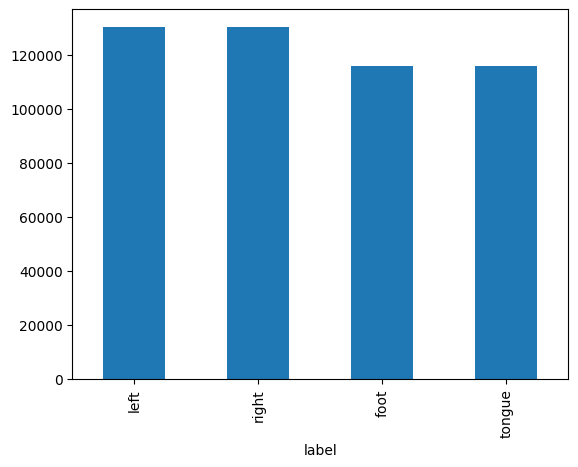

In [92]:
import matplotlib.pyplot as plt
data["label"].value_counts().plot(kind="bar"); plt.show()

In [93]:
# Step 1: Clean the data
data = data.dropna()
data = data[~data['label'].isin(['foot', 'tongue'])]


In [94]:
# Ensure EEG channels are numeric
eeg_columns = data.columns[4:]
data[eeg_columns] = data[eeg_columns].apply(pd.to_numeric, errors='coerce')
data = data.dropna()

In [95]:
# Step 2: Check class distribution
print("Class distribution before windowing:")
print(data['label'].value_counts())

Class distribution before windowing:
label
right    130248
left     130248
Name: count, dtype: int64


In [96]:
# Step 3: Group data by epoch
grouped = data.groupby('epoch')

X = []
y = []

In [97]:
for epoch, group in grouped:
    data = group[eeg_columns].values.T  # Shape: (n_channels, n_time_points)
    
    # Ensure consistent length (trim or pad)
    target_length = 201
    if data.shape[1] > target_length:
        data = data[:, :target_length]
    elif data.shape[1] < target_length:
        pad_width = target_length - data.shape[1]
        data = np.pad(data, ((0, 0), (0, pad_width)), mode='constant')
    
    X.append(data)
    label = group['label'].iloc[0]
    y.append(label)

# Convert to numpy arrays
X = np.array(X)  # Shape: (n_samples, channels, time_points)
y = np.array(y)

In [98]:
# Step 4: Channel-wise normalization
n_samples, n_channels, n_time_points = X.shape
X_normalized = np.zeros_like(X)

for i in range(n_samples):
    for ch in range(n_channels):
        channel_data = X[i, ch, :]
        scaler = StandardScaler()
        X_normalized[i, ch, :] = scaler.fit_transform(channel_data.reshape(-1, 1)).flatten()

In [99]:
# Step 5: Compute frequency-domain features using FFT
X_freq = np.zeros((n_samples, n_channels, n_time_points // 2 + 1))  # FFT output length
for i in range(n_samples):
    for ch in range(n_channels):
        fft_result = fft(X_normalized[i, ch, :])
        X_freq[i, ch, :] = np.abs(fft_result[:n_time_points // 2 + 1])  # Take magnitude of first half


In [100]:
# Step 6: Sliding window to increase samples
window_size = 50
stride = 10
X_windows = []
y_windows = []

In [101]:
for i in range(n_samples):
    data = X_normalized[i]  # Shape: (channels, time_points)
    freq_data = X_freq[i]   # Shape: (channels, freq_points)
    num_windows = (n_time_points - window_size) // stride + 1
    
    for w in range(num_windows):
        start = w * stride
        end = start + window_size
        window = data[:, start:end]  # Shape: (channels, window_size)
        
        # Extract frequency features for this window (approximate by slicing)
        freq_start = (start * (n_time_points // 2 + 1)) // n_time_points
        freq_end = (end * (n_time_points // 2 + 1)) // n_time_points
        freq_window = freq_data[:, freq_start:freq_end]
        
        # Ensure freq_window matches window_size by interpolation or padding
        freq_len = freq_end - freq_start
        if freq_len < window_size:
            freq_window = np.pad(freq_window, ((0, 0), (0, window_size - freq_len)), mode='constant')
        elif freq_len > window_size:
            freq_window = freq_window[:, :window_size]
        
        # Combine time and frequency features
        combined = np.stack([window, freq_window], axis=-1)  # Shape: (channels, window_size, 2)
        X_windows.append(combined)
        y_windows.append(y[i])

# Convert to numpy arrays
X_windows = np.array(X_windows)  # Shape: (n_windows, channels, window_size, 2)
y_windows = np.array(y_windows)

In [102]:
# Step 7: Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_windows)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

In [103]:
# Step 8: Reshape for CNN-LSTM: (samples, time_steps, channels, features)
X_windows = X_windows.transpose(0, 2, 1, 3)  # Shape: (n_windows, window_size, channels, 2)
# Reshape to (samples, time_steps, channels * features) for Conv1D
X_windows = X_windows.reshape(X_windows.shape[0], X_windows.shape[1], X_windows.shape[2] * X_windows.shape[3])  # Shape: (n_windows, 50, 22 * 2)

In [104]:
# Step 9: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

In [105]:
# Verify shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7091, 50, 44)
y_train shape: (7091, 2)
X_test shape: (1773, 50, 44)
y_test shape: (1773, 2)


In [106]:
# --- Simple CNN-LSTM Model ---
def CNN_LSTM(nb_classes=2, Chans=22, Samples=50, dropoutRate=0.3, Features=2):
    """
    Simple CNN-LSTM model for EEG-based binary classification with time and frequency features.
    
    Parameters:
    - nb_classes: Number of classes (2 for binary classification)
    - Chans: Number of EEG channels (22)
    - Samples: Number of time points (window size = 50)
    - dropoutRate: Dropout rate for regularization
    - Features: Number of features (time + frequency = 2)
    """
    input_shape = (Samples, Chans * Features)  # Shape: (time_steps, channels * features)
    l2_reg = 0.002

    # Input layer
    input1 = Input(shape=input_shape)

    # CNN layers to extract features
    x = Conv1D(32, kernel_size=3, padding='same', activation='elu',
               kernel_regularizer=l2(l2_reg))(input1)
    x = BatchNormalization()(x)
    x = Dropout(dropoutRate)(x)

    x = Conv1D(64, kernel_size=3, padding='same', activation='elu',
               kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)  # (50 → 25)
    x = Dropout(dropoutRate)(x)

    # LSTM layers to capture temporal dependencies
    x = LSTM(128, return_sequences=True, dropout=dropoutRate)(x)
    x = LSTM(64, dropout=dropoutRate)(x)

    # Dense layers for classification
    x = Dense(64, activation='elu', kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(dropoutRate)(x)
    x = Dense(nb_classes, activation='softmax')(x)

    # Create model
    model = Model(inputs=input1, outputs=x)
    
    return model

In [107]:
# Instantiate and compile the model
model = CNN_LSTM(nb_classes=2, Chans=22, Samples=50, dropoutRate=0.3, Features=2)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [108]:
# Model summary
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 50, 44)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 50, 32)         │         4,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 50, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 25, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,362 (638.13 KB)

 Trainable params: 163,170 (637.38 KB)

 Non-trainable params: 192 (768.00 B)

In [109]:
# --- Training ---
early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max')
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(X_train, y_train,
                   batch_size=32,
                   epochs=200,
                   validation_data=(X_test, y_test),
                   callbacks=[early_stopping, lr_scheduler],
                   verbose=1)

Epoch 1/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.5142 - loss: 0.9462 - val_accuracy: 0.5516 - val_loss: 0.8966 - learning_rate: 5.0000e-04
Epoch 2/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.5264 - loss: 0.8747 - val_accuracy: 0.5460 - val_loss: 0.8462 - learning_rate: 5.0000e-04
Epoch 3/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.5610 - loss: 0.8262 - val_accuracy: 0.5685 - val_loss: 0.8079 - learning_rate: 5.0000e-04
Epoch 4/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.5728 - loss: 0.7915 - val_accuracy: 0.5877 - val_loss: 0.7759 - learning_rate: 5.0000e-04
Epoch 5/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.5834 - loss: 0.7687 - val_accuracy: 0.5888 - val_loss: 0.7527 - learning_rate: 5.0000e-04
Epoch 6/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.5978 - loss: 0.7449 - val_accuracy: 0.5860 - val_loss: 0.7472 - learning_rate: 5.0000e-04
Epoch 7/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8342 - loss: 0.4559
Test accuracy: 0.8342


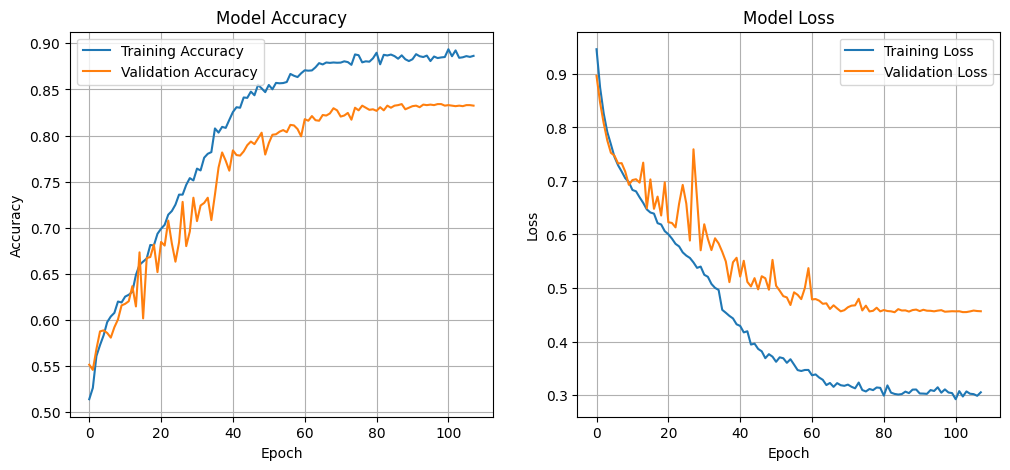

In [110]:
# --- Evaluation ---
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

# --- Plotting Results ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# plt.tight_layout()
# plt.savefig('training_plots_reshaped_input.png')

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


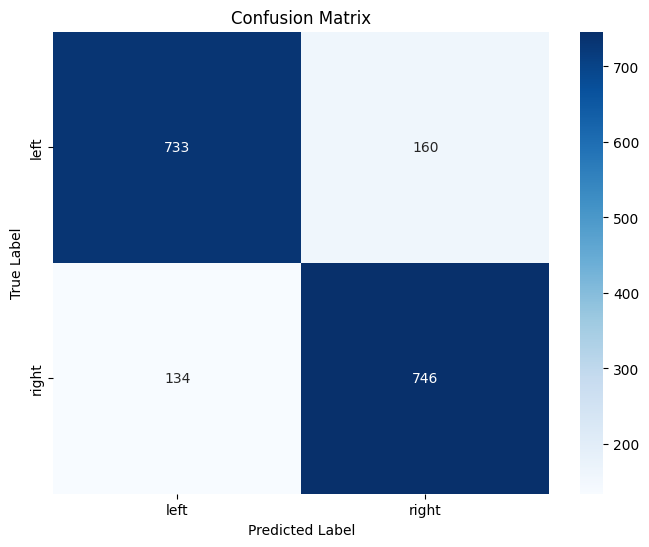

Accuracy Score: 0.8341793570219966

Classification Report:
              precision    recall  f1-score   support

        left       0.85      0.82      0.83       893
       right       0.82      0.85      0.84       880

    accuracy                           0.83      1773
   macro avg       0.83      0.83      0.83      1773
weighted avg       0.83      0.83      0.83      1773

[[733 160]
 [134 746]]


In [121]:
from sklearn.metrics import confusion_matrix, classification_report
import sklearn.metrics as metrics
import seaborn as sns
# --- Compute Predictions ---
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test_classes, y_pred_classes)
class_names = label_encoder.classes_  # Should be ['left', 'right']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
# plt.savefig('confusion_matrix.png')
score = metrics.accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy Score:", score)
# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=class_names))
print(cm)